In [1]:
# Imports and Configurations
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time

# Clustering and distance metrics
from dtaidistance import dtw
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

# Parallelization for OCP
import multiprocessing as mp

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

np.random.seed(42)

# Configuration
BENCHMARK        = '^GSPC'
RISK_FREE_RATE   = 0.045
START_DATE       = '2014-01-01'
END_DATE         = '2024-01-01'
ROLLING_WINDOW   = 52
MIN_HISTORY      = 400
K_VALUES         = [2,4,7]
N_CORES          = 14

# Three-period out-of-sample validation framework
TRAIN_START = '2014-01-01'
TRAIN_END   = '2017-12-31'
VAL_START   = '2018-01-01'
VAL_END     = '2020-12-31'
TEST_START  = '2021-01-01'
TEST_END    = '2023-12-31'

# Strategy Parameters
ZSCORE_WINDOW   = 52
VOL_WINDOW      = 26
VOL_THRESHOLD   = 1.5
HIGH_VOL_ENTRY  = 2.5
LOW_VOL_ENTRY   = 1.5
STANDARD_ENTRY  = 2.0
EXIT_THRESHOLD  = 0.5
STOP_LOSS       = 3.5

print('Notebook 6: DTW vs. OCP Clustering - S&P 500 Universe')
print(f'Period: {START_DATE} to {END_DATE}')
print(f'Risk-free rate: {RISK_FREE_RATE} (applied to both DTW and OCP Sharpe inputs)')
print(f'Parallelization: {N_CORES} cores for OCP')
print(f'\nThree-period framework (for later validation stage):')
print(f'    Train: {TRAIN_START} to {TRAIN_END}')
print(f'    Val:   {VAL_START} to {VAL_END}')
print(f'    Test:  {TEST_START} to {TEST_END}')
print(f'\nStrategy parameters (for later backtest stage):')
print(f'    Entry: ±{HIGH_VOL_ENTRY}σ (high vol) / ±{LOW_VOL_ENTRY}σ (low vol)')
print(f'    Exit:  ±{EXIT_THRESHOLD}σ')
print(f'    Stop:  ±{STOP_LOSS}σ')

Notebook 6: DTW vs. OCP Clustering - S&P 500 Universe
Period: 2014-01-01 to 2024-01-01
Risk-free rate: 0.045 (applied to both DTW and OCP Sharpe inputs)
Parallelization: 14 cores for OCP

Three-period framework (for later validation stage):
    Train: 2014-01-01 to 2017-12-31
    Val:   2018-01-01 to 2020-12-31
    Test:  2021-01-01 to 2023-12-31

Strategy parameters (for later backtest stage):
    Entry: ±2.5σ (high vol) / ±1.5σ (low vol)
    Exit:  ±0.5σ
    Stop:  ±3.5σ


In [2]:
# Retrieving S&P500 constituents as of January 1, 2014

# This source avoids survivorship bias
hist_url = (
    'https://raw.githubusercontent.com/fja05680/sp500/master/'
    'S%26P%20500%20Historical%20Components%20%26%20Changes.csv'
)

hist = pd.read_csv(hist_url)
hist['date'] = pd.to_datetime(hist['date'])

# Finding the row closest to our target date
target_date = pd.Timestamp('2014-01-01')
snapshot_row = hist[hist['date'] <= target_date].sort_values('date').iloc[-1]

print(f'Using snapshot date: {snapshot_row['date'].date()}')

sp500_tickers_2014 = sorted(snapshot_row['tickers'].split(','))

sp500_tickers_2014 = [t.strip().replace('.','-') for t in sp500_tickers_2014]

print(f'S&P 500 constituents as of {target_date.date()}: {len(sp500_tickers_2014)} stocks')
print(f'\nFirst 10 tickers: {sp500_tickers_2014[:10]}')

Using snapshot date: 2013-12-31
S&P 500 constituents as of 2014-01-01: 502 stocks

First 10 tickers: ['A', 'AABA', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM']


In [3]:
# Downloading price date for the S&P 500 2014 universe
import yfinance as yf

print(f'Downloading price data for {len(sp500_tickers_2014)} stocks..')
print(f'Period: {START_DATE} to {END_DATE}, weekly (Wednesday), adjusted close\n')

raw = yf.download(
    sp500_tickers_2014,
    start=START_DATE,
    end=END_DATE,
    interval='1wk',
    auto_adjust=True,
    progress=True
)

price_data = raw['Close']
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')

# Dropping any ticker without complete history across the full window 
before_drop = price_data.shape[1]
price_data  = price_data.ffill().dropna(axis=1)
after_drop  = price_data.shape[1]

# Dropping tickers that are flatlined through the end of the series
TAIL_WINDOW = 10

flatlined = []
for t in price_data.columns:
    tail = price_data[t].iloc[-TAIL_WINDOW:]
    if tail.nunique()==1:
        flatlined.append(t)

price_data = price_data.drop(columns=flatlined)
after_drop = price_data.shape[1]

print(f'\nPrice data shape: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Tickers with complete history: {after_drop} (dropped {before_drop - after_drop} incomplete/delisted)')

dropped_tickers = sorted(set(sp500_tickers_2014) - set(price_data.columns))
print(f'\nDropped tickers ({len(dropped_tickers)}): {dropped_tickers}')

print("""
    Data source limitation note (for methodology section / paper writeup):

    yfinance (via Yahoo Finance) does not serve historical price data for
    tickers that have since delisted, regardless of how far in the past
    the requested date range is. This means out S&P 500 2014 universe is
    effectively: 'constituents as of Jan 2014 whose historical data 
    remains accessible via Yahoo Finance of the analysis date' (July 2026),
    not strictly 'constituents as of Jan 2014.' Companies that were acquired,
    taken private, or delisted at any point between 2014 and today are absent 
    even though they had complete price history during the actual 2014-2023 
    study window (verified via individual re-download diagnostic; confirmed 
    cases include WBA, acquired Sycamore Partners Aug 2025, and K/Kellanova,
    acquired by Mars Dec 2025).
""")

print("""
    This is a known constraint of free retail data vendors and differs 
    from the CRSP/WRDS standard in academic finance, which preserves
    full historical records for delisted securities. Disclosed here as
    a limitation rather than corrected, per project scope.
""")

Period: 2014-01-01 to 2024-01-01, weekly (Wednesday), adjusted close



$SIAL-201511: possibly delisted; no timezone found
[                       0%                       ]$CTXS: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CFN-201503"}}}
$COG: possibly delisted; no timezone found
$CFN-201503: possibly delisted; no timezone found]  3 of 502 completed
$PKI: possibly delisted; no timezone found       ]  17 of 502 completed
$UTX: possibly delisted; no timezone found       ]  20 of 502 completed
$DFS: possibly delisted; no timezone found       ]  21 of 502 completed
[**                     4%                       ]  22 of 502 completed$HCBK-201510: possibly delisted; no timezone found
[**                     5%                       ]  24 of 502 completed$SRCL: possibly delisted; no timezone found
$LM: possibly delisted; no timezone found        ]  32 of 502 completed
$K: possibly delisted; no timezone found
[***                    7%                


Price data shape: (522, 356)
Date range: 2014-01-01 to 2023-12-27
Tickers with complete history: 356 (dropped 146 incomplete/delisted)

Dropped tickers (146): ['AABA', 'ABC', 'ADS', 'ADT-201604', 'AET', 'AGN', 'AGN-201503', 'ALTR-201512', 'ALXN', 'ANDV', 'ANTM', 'APC', 'ARG-201605', 'ARNC', 'AVP', 'BCR-201712', 'BEAM-201404', 'BHGE', 'BK', 'BLL', 'BMS', 'BRCM-201601', 'BTUUQ-201704', 'CA', 'CAM-201604', 'CB-201601', 'CBS', 'CCE', 'CELG', 'CERN', 'CFN-201503', 'CHK', 'CMA', 'COG', 'COL', 'COV-201501', 'CTL', 'CTXS', 'CVC-201606', 'DD-201708', 'DFS', 'DISCA', 'DNB', 'DNR', 'DO', 'DOW-201708', 'DTV-201507', 'EMC-201609', 'ESRX', 'ESV', 'ETFC', 'FB', 'FDO-201507', 'FLIR', 'FOXA', 'FRX-201406', 'FTI-201701', 'FTR', 'GAS-201606', 'GGP', 'GGP-201808', 'GPS', 'HAR-201703', 'HCBK-201510', 'HCP', 'HES', 'HOT-201609', 'HRS', 'HSP-201509', 'IGT-201504', 'IPG', 'IR', 'JCI-201609', 'JEC', 'JNPR', 'JOY-201704', 'JWN', 'K', 'KORS', 'KRFT-201507', 'KSU', 'LB', 'LIFE-201402', 'LLL', 'LLTC-201703', 'LM'

In [4]:
# Computing weekly log returns
log_returns = np.log(price_data / price_data.shift(1))

# Computing rolling sharpe ratio (risk-free-rate adjusted)
weekly_rf = RISK_FREE_RATE / 52

rolling_mean = log_returns.rolling(window=ROLLING_WINDOW).mean()
rolling_std  = log_returns.rolling(window=ROLLING_WINDOW).std()

sharpe_data = ((rolling_mean - weekly_rf) / rolling_std) * np.sqrt(52)
sharpe_data = sharpe_data.dropna(how='all')

print(f'Sharpe data shape: {sharpe_data.shape}')
print(f'Date range: {sharpe_data.index[0].date()} to {sharpe_data.index[-1].date()}')
print(f'\nSample (first 5 stocks, last 5 weeks):')
print(sharpe_data.iloc[-5:, :5])

Sharpe data shape: (470, 356)
Date range: 2014-12-31 to 2023-12-27

Sample (first 5 stocks, last 5 weeks):
Ticker           A   AAPL    ABBV     ABT    ACN
Date                                            
2023-11-29 -0.7661 1.0807 -0.6945 -0.0990 0.5231
2023-12-06 -0.9031 1.0364 -0.3981 -0.3568 0.4765
2023-12-13 -0.3472 1.6246 -0.2563 -0.0380 1.0699
2023-12-20 -0.3871 1.6103 -0.2996 -0.1010 1.1574
2023-12-27 -0.4190 1.8141 -0.2687 -0.1095 1.0423


In [5]:
# Computing DTW distance matrix for the S&P500 universe
tickers = sharpe_data.columns.tolist()
n = len(tickers)
print(f'Computing DTW distances for {n} stocks ({n*(n-1)//2} pairs)...')

# dtaidistance requires float64, contiguous arrays
series = [sharpe_data[t].values.astype(np.float64) for t in tickers]

start_time = time.time()
dtw_distance_matrix = dtw.distance_matrix_fast(series)
elapsed = time.time() - start_time

print(f'\nDTW distance matrix computed in {elapsed:.1f} seconds')
print(f'Matrix shape: {dtw_distance_matrix.shape}')

dtw_distance_matrix[dtw_distance_matrix == np.inf] = 0
dtw_distance_matrix = dtw_distance_matrix + dtw_distance_matrix.T

print(f'\nSample of distance matrix (first 5x5):')
print(pd.DataFrame(dtw_distance_matrix[:5, :5], index=tickers[:5], columns=tickers[:5]))

Computing DTW distances for 356 stocks (63190 pairs)...

DTW distance matrix computed in 43.2 seconds
Matrix shape: (356, 356)

Sample of distance matrix (first 5x5):
           A    AAPL    ABBV     ABT     ACN
A     0.0000 24.5659 14.8006 15.2052 16.3658
AAPL 24.5659  0.0000 17.5195 15.7653 17.3474
ABBV 14.8006 17.5195  0.0000 11.2330 14.8815
ABT  15.2052 15.7653 11.2330  0.0000 15.4223
ACN  16.3658 17.3474 14.8815 15.4223  0.0000


k=2: clusters sizes = [178, 178]
k=4: clusters sizes = [99, 79, 71, 107]
k=7: clusters sizes = [56, 43, 26, 53, 71, 52, 55]


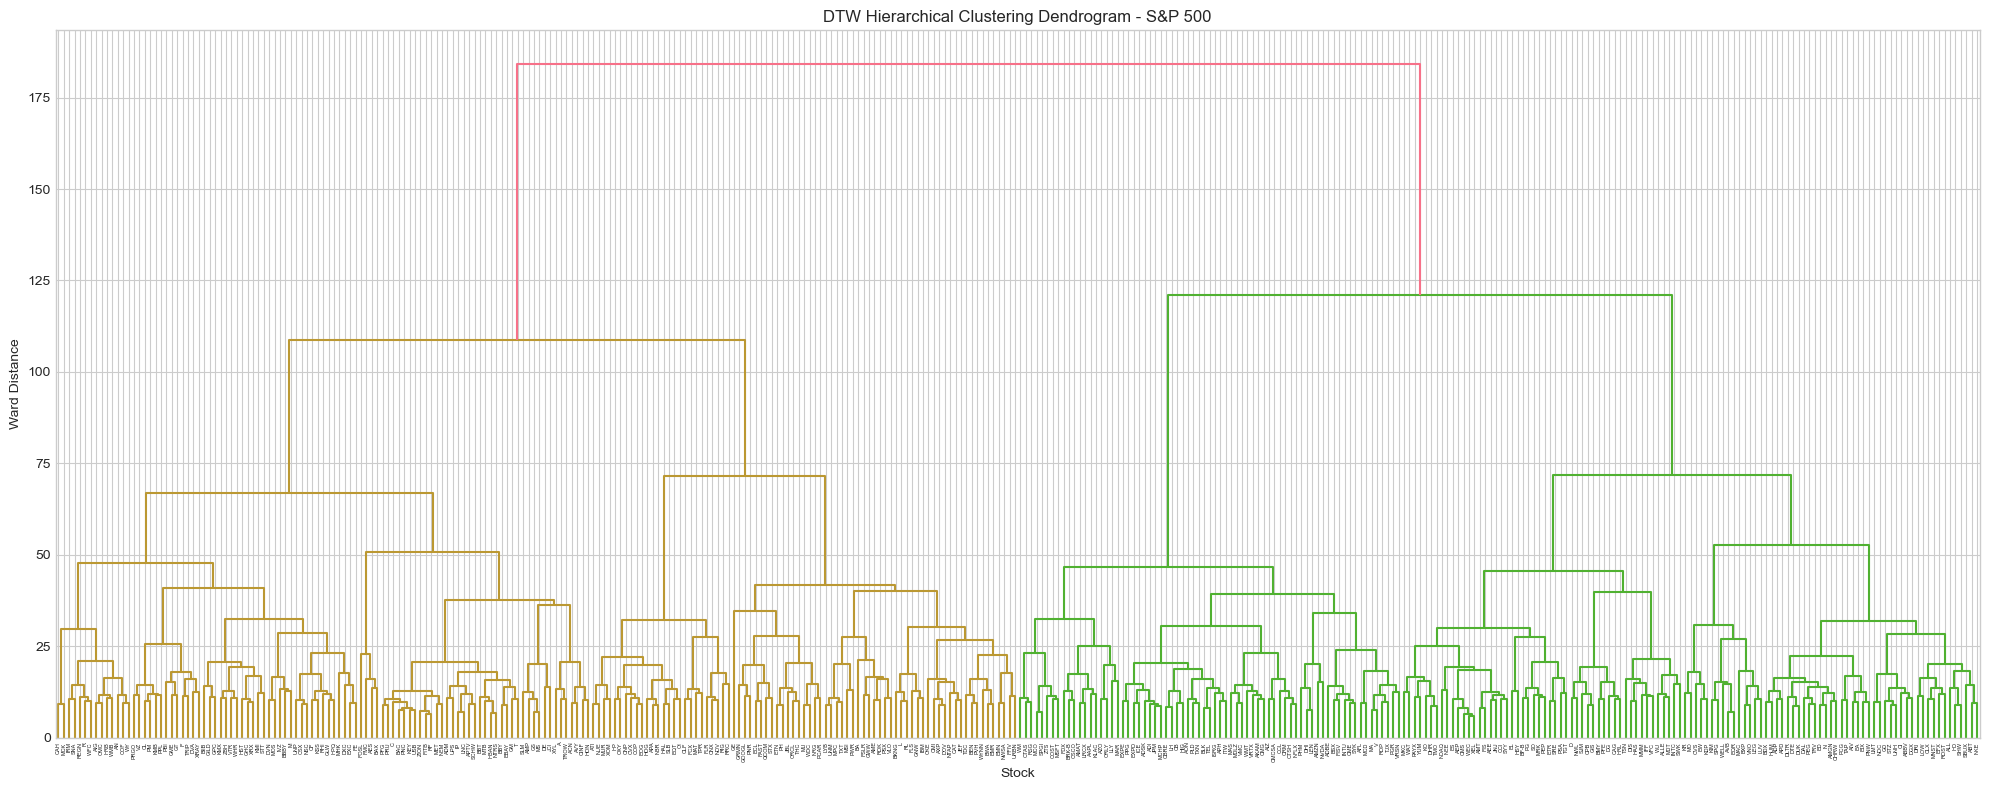


DTW cluster assignments saved to dtw_cluster_df
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           1           1           2
1   AAPL           2           3           5
2   ABBV           2           4           7
3    ABT           2           4           7
4    ACN           1           1           2


In [6]:
# DTW hierarchical clustering (k=2, 4, 7), Ward linkage
condensed_dtw = squareform(dtw_distance_matrix)
dtw_linkage = linkage(condensed_dtw, method='ward')

dtw_clusters = {}
for k in K_VALUES:
    dtw_clusters[k] = fcluster(dtw_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(dtw_clusters[k]).value_counts().sort_index()
    print(f'k={k}: clusters sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(dtw_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('DTW Hierarchical Clustering Dendrogram - S&P 500')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dtw_dendrogram_sp500.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing cluster assignments in a DataFrame for later use (cointegration testing)
dtw_cluster_df = pd.DataFrame({'ticker': tickers})
for k in K_VALUES:
    dtw_cluster_df[f'cluster_k{k}'] = dtw_clusters[k]

print(f'\nDTW cluster assignments saved to dtw_cluster_df')
print(dtw_cluster_df.head())

In [7]:
# Cluster validation indices for DTW clustering, same three metrics
dtw_cvi_results = []

for k in K_VALUES:
    labels = dtw_clusters[k]

    # Silhouette score using DTW distance matrix directly
    sil = silhouette_score(dtw_distance_matrix, labels, metric='precomputed')

    # Calinsk-Harabasz and Davies Bouldin using raw Sharpe ratio scores
    ch = calinski_harabasz_score(sharpe_data.T, labels)
    db = davies_bouldin_score(sharpe_data.T, labels)

    dtw_cvi_results.append({
        'k': k,
        'silhouette': sil, 
        'calinski_harabasz': ch, 
        'davies_boudlin': db
    })

    print(f'k={k}: silhouette={sil:.4f}, calinski_harabasz={ch:.2f}, davies_bouldin={db:.4f}')

dtw_cvi_df = pd.DataFrame(dtw_cvi_results)
print('\nDTW Cluster Validation Summary:')
print(dtw_cvi_df)

k=2: silhouette=0.1573, calinski_harabasz=42.28, davies_bouldin=2.8313
k=4: silhouette=0.1013, calinski_harabasz=25.35, davies_bouldin=3.4034
k=7: silhouette=0.0795, calinski_harabasz=18.49, davies_bouldin=3.2939

DTW Cluster Validation Summary:
   k  silhouette  calinski_harabasz  davies_boudlin
0  2      0.1573            42.2824          2.8313
1  4      0.1013            25.3512          3.4034
2  7      0.0795            18.4860          3.2939


In [8]:
# OCP (Optimal Causal Path) distance function

def ocp_distance(x,y):
    """
    Computes the Optimal Causal Path distance between two time series.
    Enforces causality: only allows the warping path to move through
    cells where j >= i, blocking the lower triangle of the cost matrix
    so futre observation in y can never be matched to past observations 
    in x (prevents look-ahead in the alignment itself).
    """
    n, m = len(x), len(y)
    cost = np.full((n, m), np.inf)
    cost[0, 0] = abs(x[0] - y[0])

    for i in range(n):
        for j in range(m):
            if j < i:
                continue  
            if i == 0 and j == 0:
                continue  
            candidates = []
            if i > 0:
                candidates.append(cost[i - 1, j])
            if j > 0:
                candidates.append(cost[i, j - 1])
            if i > 0 and j > 0:
                candidates.append(cost[i - 1, j - 1])
            cost[i, j] = abs(x[i] - y[j]) + min(candidates)

    return cost[n - 1, m - 1]

def ocp_symmetric(x, y):
    """
    Computes OCP distance in both direction and takes the minimum,
    improving on Stubinger (2019) who assumes a fixed lead direction.
    """
    return min(ocp_distance(x, y), ocp_distance(y, x))   

In [9]:
!pip install multiprocess

In [10]:
from multiprocess import Pool 

def ocp_pair_worker(args):
    import numpy as np  
                        
    def _ocp_distance(x, y):
        n, m = len(x), len(y)
        cost = np.full((n, m), np.inf)
        cost[0, 0] = abs(x[0] - y[0])
        for i in range(n):
            for j in range(m):
                if j < i:
                    continue
                if i == 0 and j == 0:
                    continue
                candidates = []
                if i > 0:
                    candidates.append(cost[i - 1, j])
                if j > 0:
                    candidates.append(cost[i, j - 1])
                if i > 0 and j > 0:
                    candidates.append(cost[i - 1, j - 1])
                cost[i, j] = abs(x[i] - y[j]) + min(candidates)
        return cost[n - 1, m - 1]

    i, j, x, y = args
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    d = min(_ocp_distance(x, y), _ocp_distance(y, x))
    return i, j, d

tickers = sharpe_data.columns.tolist()
n = len(tickers)

tasks = []
for i in range(n):
    for j in range(i + 1, n):
        x = sharpe_data.iloc[:, i].values
        y = sharpe_data.iloc[:, j].values
        tasks.append((i, j, x, y))

print(f'Total pairs to compute: {len(tasks)}')
print(f'Using {N_CORES} cores')

start_time = time.time()
ocp_matrix = np.zeros((n,n))

with Pool(processes=N_CORES) as pool:
    completed = 0
    for i, j, d in pool.imap_unordered(ocp_pair_worker, tasks, chunksize=50):
        ocp_matrix[i, j] = d
        ocp_matrix[j, i] = d
        completed += 1
        if completed % 2000 == 0:           
            elapsed = time.time() - start_time
            pct = completed / len(tasks) * 100
            eta = (elapsed / completed) * (len(tasks) - completed)
            print(f'  {completed}/{len(tasks)} ({pct:.1f}%) - elapsed {elapsed:.0f}s - ETA {eta:.0f}s')
        if completed % 10000 == 0:
            np.save('ocp_distance_matrix_sp500_checkpoint.npy', ocp_matrix)
            print(f'  [checkpoint saved at {completed} pairs]')

elapsed = time.time() - start_time
print(f'\nOCP distance matrix computed in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)')
print(f'Matrix shape: {ocp_matrix.shape}')

# Saving immediately, same pattern as Notebook 5
np.save('ocp_distance_matrix_sp500.npy', ocp_matrix)
pd.Series(tickers).to_csv('ocp_tickers_sp500.csv', index=False)
sharpe_data.to_csv('ocp_sharpe_data_sp500.csv')
print('\nSaved: ocp_distance_matrix_sp500.npy, ocp_tickers_sp500.csv, ocp_sharpe_data_sp500.csv')

Total pairs to compute: 63190
Using 14 cores
  2000/63190 (3.2%) - elapsed 285s - ETA 8710s
  4000/63190 (6.3%) - elapsed 568s - ETA 8400s
  6000/63190 (9.5%) - elapsed 850s - ETA 8099s
  8000/63190 (12.7%) - elapsed 1125s - ETA 7764s
  10000/63190 (15.8%) - elapsed 1399s - ETA 7439s
  [checkpoint saved at 10000 pairs]
  12000/63190 (19.0%) - elapsed 1676s - ETA 7150s
  14000/63190 (22.2%) - elapsed 1894s - ETA 6655s
  16000/63190 (25.3%) - elapsed 2159s - ETA 6369s
  18000/63190 (28.5%) - elapsed 2428s - ETA 6095s
  20000/63190 (31.7%) - elapsed 2691s - ETA 5812s
  [checkpoint saved at 20000 pairs]
  22000/63190 (34.8%) - elapsed 2964s - ETA 5549s
  24000/63190 (38.0%) - elapsed 3229s - ETA 5272s
  26000/63190 (41.1%) - elapsed 3493s - ETA 4996s
  28000/63190 (44.3%) - elapsed 3711s - ETA 4664s
  30000/63190 (47.5%) - elapsed 20160s - ETA 22304s
  [checkpoint saved at 30000 pairs]
  32000/63190 (50.6%) - elapsed 20415s - ETA 19899s
  34000/63190 (53.8%) - elapsed 20565s - ETA 17656s
 

In [11]:
print(f'Non-zero distances: {np.count_nonzero(ocp_matrix)} / {ocp_matrix.size}')
print(f'Min: {ocp_matrix[ocp_matrix > 0].min():.4f}, Max: {ocp_matrix.max():.4f}, Mean: {ocp_matrix[ocp_matrix > 0].mean():.4f}')
print(pd.DataFrame(ocp_matrix[:5, :5], index=tickers[:5], columns=tickers[:5]))

Non-zero distances: 126380 / 126736
Min: 64.2708, Max: 668.2580, Mean: 206.0779
            A     AAPL     ABBV      ABT      ACN
A      0.0000 245.6815 130.4228 176.2728 162.2980
AAPL 245.6815   0.0000 178.5430 167.8660 169.9631
ABBV 130.4228 178.5430   0.0000 178.1832 180.1955
ABT  176.2728 167.8660 178.1832   0.0000 159.7979
ACN  162.2980 169.9631 180.1955 159.7979   0.0000


k=2: cluster sizes = [105, 251]
k=4: cluster sizes = [42, 63, 150, 101]
k=7: cluster sizes = [42, 34, 29, 53, 97, 46, 55]


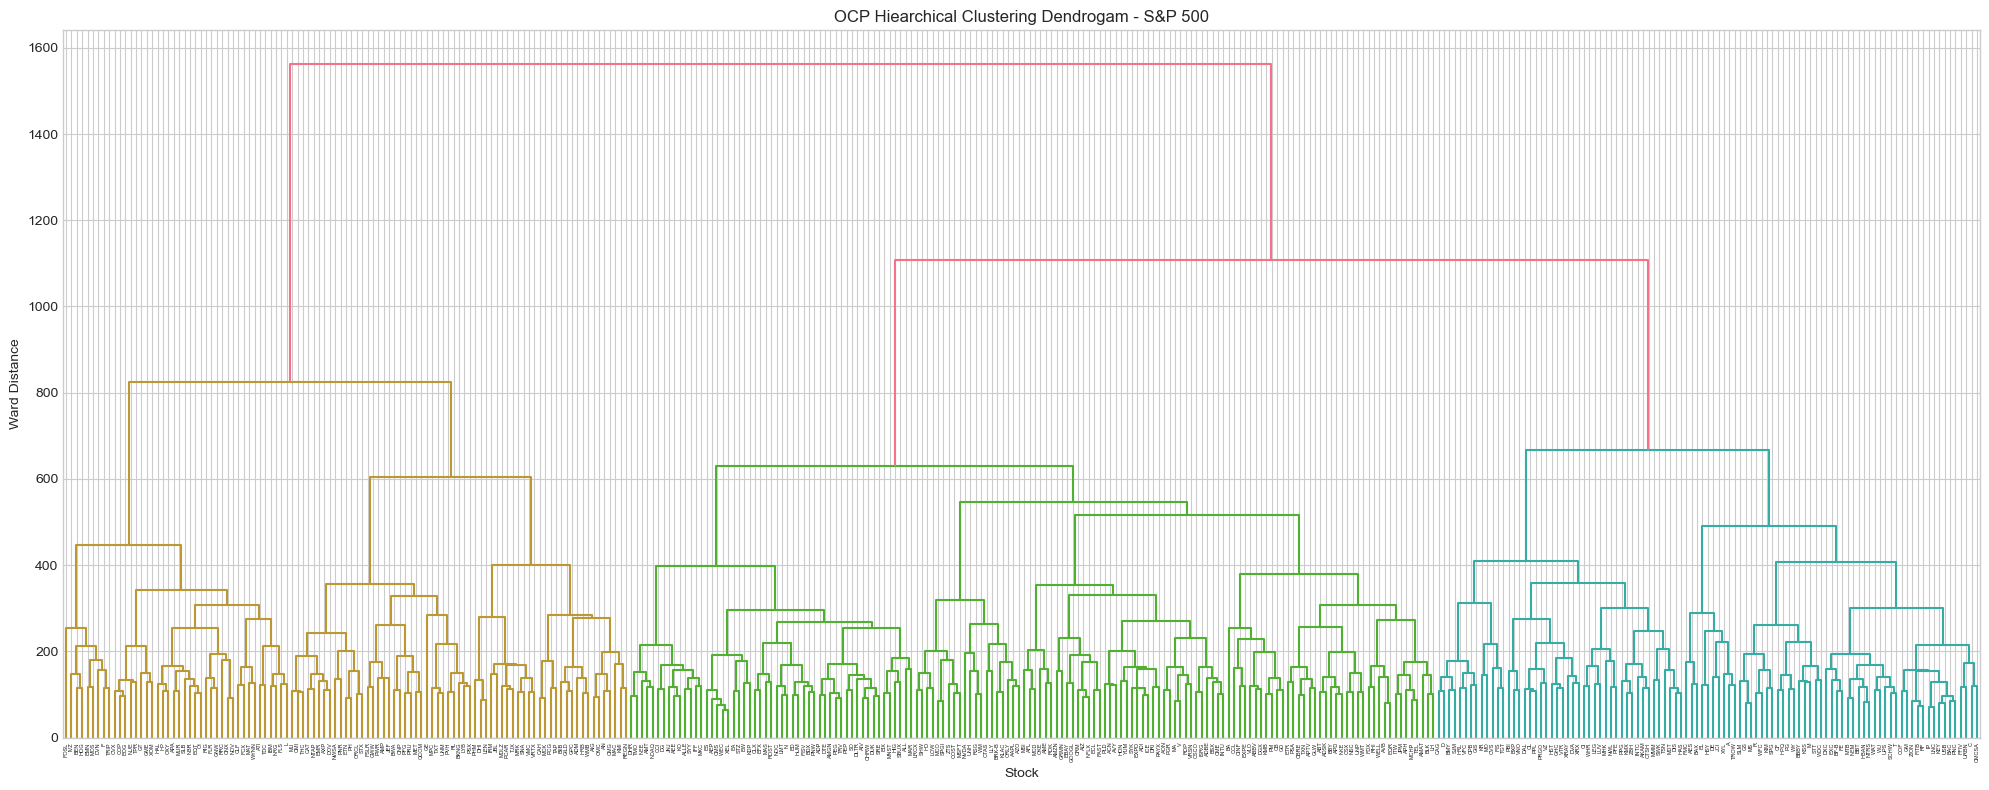


OCP cluster assingments saved to ocp_cluster_df
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           2           4           7
1   AAPL           2           3           5
2   ABBV           2           3           5
3    ABT           2           3           5
4    ACN           2           3           5


In [13]:
# OCP hieararchical clustering (k=2, 4, 7), Ward linkage
condensed_ocp = squareform(ocp_matrix)
ocp_linkage = linkage(condensed_ocp, method='ward')

ocp_clusters = {}
for k in K_VALUES:
    ocp_clusters[k] = fcluster(ocp_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(ocp_clusters[k]).value_counts().sort_index()
    print(f'k={k}: cluster sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(ocp_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('OCP Hiearchical Clustering Dendrogam - S&P 500')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('ocp_dendrogam_sp500.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing clusters assignments for later use (cointegration testing)
ocp_cluster_df = pd.DataFrame({'ticker':tickers})
for k in K_VALUES:
    ocp_cluster_df[f'cluster_k{k}'] = ocp_clusters[k]

print(f'\nOCP cluster assingments saved to ocp_cluster_df')
print(ocp_cluster_df.head())